<a href="https://colab.research.google.com/github/olkanth/MSCS_634_ProjectDeliverable_1/blob/main/MSCS_634_Project_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 1: Data Collection, Cleaning, and Exploration

# 1. Dataset Selection

The **Diabetes Health Indicators Dataset** was selected from Kaggle (CDC BRFSS 2015 survey data). It contains:
- **4,238 records**
- **16 attributes (15 input features + 1 target)**
- **Target variable:** `TenYearCHD` — binary (0/1), suitable for classification

Dataset on Kaggle: https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset


In [45]:
# Immport necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import KNNImputer


In [31]:
# Upload dataset file (framingham.csv)
from google.colab import files

uploaded = files.upload()
uploaded

Saving framingham.csv to framingham.csv


{'framingham.csv': b'male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD\r1,39,4,0,0,0,0,0,0,195,106,70,26.97,80,77,0\r0,46,2,0,0,0,0,0,0,250,121,81,28.73,95,76,0\r1,48,1,1,20,0,0,0,0,245,127.5,80,25.34,75,70,0\r0,61,3,1,30,0,0,1,0,225,150,95,28.58,65,103,1\r0,46,3,1,23,0,0,0,0,285,130,84,23.1,85,85,0\r0,43,2,0,0,0,0,1,0,228,180,110,30.3,77,99,0\r0,63,1,0,0,0,0,0,0,205,138,71,33.11,60,85,1\r0,45,2,1,20,0,0,0,0,313,100,71,21.68,79,78,0\r1,52,1,0,0,0,0,1,0,260,141.5,89,26.36,76,79,0\r1,43,1,1,30,0,0,1,0,225,162,107,23.61,93,88,0\r0,50,1,0,0,0,0,0,0,254,133,76,22.91,75,76,0\r0,43,2,0,0,0,0,0,0,247,131,88,27.64,72,61,0\r1,46,1,1,15,0,0,1,0,294,142,94,26.31,98,64,0\r0,41,3,0,0,1,0,1,0,332,124,88,31.31,65,84,0\r0,39,2,1,9,0,0,0,0,226,114,64,22.35,85,NA,0\r0,38,2,1,20,0,0,1,0,221,140,90,21.35,95,70,1\r1,48,3,1,10,0,0,1,0,232,138,90,22.37,64,72,0\r0,46,2,1,20,0,0,0,0,291,112,78,23.38,80,89,1\r0,38,2,1,5,0

## 2. Load the dataset using Pandas and inspect its structure.

In [62]:
# -----------------------------------------------------------
# Load dataset and inspect.
# Shape: 253,680 rows × 22 columns
# RangeIndex: 4240 entries, 0 to 4239
# Data columns (total 16 columns):
#  #   Column           Non-Null Count  Dtype
# ---  ------           --------------  -----
#  0   male             4240 non-null   int64
#  1   age              4240 non-null   int64
#  2   education        4135 non-null   float64
#  3   currentSmoker    4240 non-null   int64
#  4   cigsPerDay       4211 non-null   float64
#  5   BPMeds           4187 non-null   float64
#  6   prevalentStroke  4240 non-null   int64
#  7   prevalentHyp     4240 non-null   int64
#  8   diabetes         4240 non-null   int64
#  9   totChol          4190 non-null   float64
#  10  sysBP            4240 non-null   float64
#  11  diaBP            4240 non-null   float64
#  12  BMI              4221 non-null   float64
#  13  heartRate        4239 non-null   float64
#  14  glucose          3852 non-null   float64
#  15  TenYearCHD       4240 non-null   int64

# -----------------------------------------------------------
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
df.head(200)

Dataset loaded successfully.
Shape: 4,240 rows × 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtype

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,49,2.0,1,9.0,0.0,0,0,0,226.0,106.0,71.0,22.89,85.0,57.0,0
196,1,48,1.0,1,10.0,0.0,0,0,0,308.0,117.0,76.0,30.85,65.0,54.0,1
197,0,55,2.0,1,9.0,0.0,0,0,0,248.0,157.0,82.5,22.91,89.0,83.0,0
198,0,58,2.0,1,5.0,0.0,0,0,0,215.0,170.0,86.0,29.06,75.0,98.0,0


In [33]:
print("Statistical information")
print("=" * 50)
desc = df.describe().T
# Coefficient of variation
desc["cv"] = (desc["std"] / desc["mean"]).round(3)
desc.round(3)

Statistical information


,count,mean,std,min,25%,50%,75%,max,cv
male,4240.0,0.429,0.495,0.00,0.00,0.0,1.00,1.0,1.153
age,4240.0,49.580,8.573,32.00,42.00,49.0,56.00,70.0,0.173
education,4135.0,1.979,1.020,1.00,1.00,2.0,3.00,4.0,0.515
currentSmoker,4240.0,0.494,0.500,0.00,0.00,0.0,1.00,1.0,1.012
cigsPerDay,4211.0,9.006,11.922,0.00,0.00,0.0,20.00,70.0,1.324
BPMeds,4187.0,0.030,0.170,0.00,0.00,0.0,0.00,1.0,5.725
prevalentStroke,4240.0,0.006,0.077,0.00,0.00,0.0,0.00,1.0,12.986
prevalentHyp,4240.0,0.311,0.463,0.00,0.00,0.0,1.00,1.0,1.490
diabetes,4240.0,0.026,0.158,0.00,0.00,0.0,0.00,1.0,6.157
totChol,4190.0,236.700,44.591,107.00,206.00,234.0,263.00,696.0,0.188


## 3. Perform data cleaning :
- Handling missing values (e.g., imputation or removal).
- Removing duplicates or correcting inconsistent data.
- Identifying and addressing noisy data.

### 3.1 Missing values analysis

In [42]:
# -----------------------------------------------------------
# Missing values analysis
# -----------------------------------------------------------

print("Missing values analysis")
print("=" * 50)

missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame(
    {"missing_values": missing_values, "missing_percent": missing_percent})
# sort by missing_percent
missing_values_df = missing_values_df.sort_values(
    "missing_percent", ascending=False)

missing_values_df

Missing values analysis


,missing_values,missing_percent
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585
male,0,0.000000
prevalentHyp,0,0.000000
prevalentStroke,0,0.000000


### 3.2 Missing values removal / imputation

Imputation comparison for 'glucose':
  Mean imputed value   : 81.96
  Median imputed value : 78.00
  KNN avg imputed value: 81.11
  Original distribution skew: 6.215

Decision: glucose is right-skewed (skew > 0.5) => median imputation preferred.


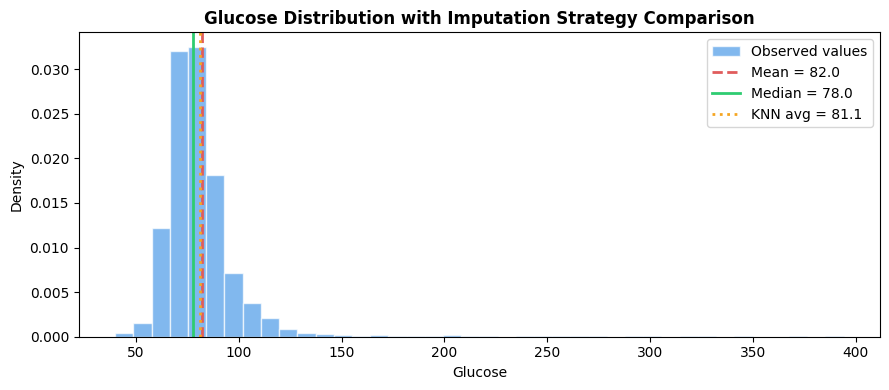

In [61]:

glucose_col = "glucose"
# remove non null Glocose values
non_null_glucose = df[glucose_col].dropna()

# Compute imputations
glucose_col_mean_val   = df[glucose_col].mean()
glucose_col_median_val = df[glucose_col].median()

# KNN imputation on the full numeric subset
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
knn_imp = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn_imp.fit_transform(df[numeric_cols]),
                      columns=numeric_cols)

# print(df_knn.head())

knn_val = df_knn.loc[df[glucose_col].isnull(), glucose_col].mean()

print(f"Imputation comparison for '{glucose_col}':")
print(f"  Mean imputed value   : {glucose_col_mean_val:.2f}")
print(f"  Median imputed value : {glucose_col_median_val:.2f}")
print(f"  KNN avg imputed value: {knn_val:.2f}")
print(f"  Original distribution skew: {non_null_glucose.skew():.3f}")
print()
print("Decision: glucose is right-skewed (skew > 0.5) => median imputation preferred.")

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(non_null_glucose, bins=40, color="#4C9BE8", edgecolor="white",
        alpha=0.7, label="Observed values", density=True)

# Mark mean, median, and KNN impute values
ax.axvline(glucose_col_mean_val,   color="#E05C5C", linestyle="--", lw=2, label=f"Mean = {glucose_col_mean_val:.1f}")
ax.axvline(glucose_col_median_val, color="#2ECC71", linestyle="-",  lw=2, label=f"Median = {glucose_col_median_val:.1f}")
ax.axvline(knn_val,    color="#F5A623", linestyle=":",  lw=2, label=f"KNN avg = {knn_val:.1f}")


ax.set_title("Glucose Distribution with Imputation Strategy Comparison", fontweight="bold")
ax.set_xlabel("Glucose")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_imputation_comparison.png", bbox_inches="tight")
plt.show()


In [74]:
# ------------------------------------------------------------------
# Apply median imputation to all numeric columns
# ------------------------------------------------------------------

# Copy the original dataframe to do all the clean up. Going forward, we will use the copied dataset
df_clean_data = df.copy()

# From the "Missing values analysis" cell, we can see below include numeric and non numeric has missing values
numeric_missing = ["glucose", "education", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
non_numeric_missing = ["education", "BPMeds"]

# Replace missing values with the median in all numeric columns
for col in numeric_missing:
    median = df[col].median()
    df_clean_data[col].fillna(median, inplace=True)
    print(f"Imputed '{col}' with median value: {median}")

# Replace missing value with the mode in non numeric columns
for col in non_numeric_missing:
    mode = df[col].mode()[0]
    df_clean_data[col].fillna(mode, inplace=True)
    print(f"Imputed '{col}' with mode value: {mode}")


remaining = df_clean_data.isnull().sum().sum()
print("=" * 50)
print(f"Reamining missing values:  {remaining}")
print()
print()

Imputed 'glucose' with median value: 78.0
Imputed 'education' with median value: 2.0
Imputed 'BPMeds' with median value: 0.0
Imputed 'totChol' with median value: 234.0
Imputed 'BMI' with median value: 25.4
Imputed 'heartRate' with median value: 75.0
Imputed 'cigsPerDay' with median value: 0.0
Imputed 'education' with mode value: 1.0
Imputed 'BPMeds' with mode value: 0.0
Reamining missing values:  0




/tmp/ipykernel_169/688459277.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean_data[col].fillna(median, inplace=True)
/tmp/ipykernel_169/688459277.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

### 3.3 Duplicate detection & Dedupe

In [77]:
# -----------------------------------------------------------
# Delete duplicates to prevent bias
# -----------------------------------------------------------

duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Number of duplicate rows : {duplicate_cnt}") # Number of duplicate rows : 0


if duplicate_cnt > 0:
  # drop the duplicates and reset index
    df_clean = df_clean_data.drop_duplicates().reset_index(drop=True)
    print(f"Removed. New shape: {df_clean_data.shape[0]:,} rows x {df_clean_data.shape[1]} columns")
else:
    print("No duplicate rows found — no removal needed.")


Number of duplicate rows : 0
No duplicate rows found — no removal needed.
